In [1]:
# sequence_aligment_picture
from Bio import SeqIO
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.patches as mpatches

def identity_to_color(base_hex, identity, ID_MIN=70, ID_MAX=100):
    FIXED_ALPHA = 0.8
    identity = np.clip(identity, ID_MIN, ID_MAX)
    ratio = (identity - ID_MIN) / (ID_MAX - ID_MIN)
    base_rgb = np.array(mcolors.hex2color(base_hex))
    start_rgb = (np.array([1.0, 1.0, 1.0]) * 2/3) + (base_rgb * 1/3)
    final_rgb = start_rgb * (1 - ratio) + base_rgb * ratio
    return (*final_rgb, FIXED_ALPHA)

def plot_synteny_blocks(ax, df, s1_line, s2_line, BASE_NORMAL="#bbbbbb", BASE_CROSS="#73a9c2", ID_MIN=70, ID_MAX=100, FIXED_ALPHA=0.5):
    s1_x_data = s1_line[0].get_xdata()
    s1_y_data = s1_line[0].get_ydata()

    s1_x_start = s1_x_data[0]
    s1_x_end   = s1_x_data[1]
    s1_y       = s1_y_data[0]

    s2_x_data = s2_line[0].get_xdata()
    s2_y_data = s2_line[0].get_ydata()

    s2_x_start = s2_x_data[0]
    s2_x_end   = s2_x_data[1]
    s2_y       = s2_y_data[0]

    def draw_single_band(s1_start, s1_end, s2_start, s2_end, identity):
        mid_y = (s1_y + s2_y) / 2
        dir_s1 = s1_end > s1_start
        dir_s2 = s2_end > s2_start
        is_cross = dir_s1 != dir_s2

        base = BASE_CROSS if is_cross else BASE_NORMAL
        color = identity_to_color(base, identity, ID_MIN=ID_MIN, ID_MAX=ID_MAX)


        verts = [
            (s1_start + s1_x_start, s1_y),
            (s1_start + s1_x_start, mid_y),
            (s2_start + s2_x_start, mid_y),
            (s2_start + s2_x_start, s2_y),
        
            (s2_end   + s2_x_start, s2_y),
            (s2_end   + s2_x_start, mid_y),
            (s1_end   + s1_x_start, mid_y),
            (s1_end   + s1_x_start, s1_y),
        
            (s1_start + s1_x_start, s1_y)
        ]
        
        codes = [
            mpath.Path.MOVETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO,
            mpath.Path.LINETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO, mpath.Path.CLOSEPOLY
        ]
        patch = mpatches.PathPatch(mpath.Path(verts, codes), facecolor=color, edgecolor="none")
        ax.add_patch(patch)

    for _, row in df.iterrows():
        draw_single_band(
            row["qstart"], row["qend"],
            row["sstart"], row["send"],
            row["pident"]
        )

def sequence_alignment(query_acc, sub_acc, contig_dict, ident_thr=90, len_thr=0):
    for acc_n in [query_acc, sub_acc]:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        os.chdir('/active-data/temp')
        temp_ncl_file = open(f'temp_nucleotide_seq-{acc_n}.fasta', 'w+')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                SeqIO.write(seq_record, temp_ncl_file, "fasta")
        temp_ncl_file.close()
        handle.close()
    
    os.chdir('/active-data/temp')
    %time os.system(f'blastn -query temp_nucleotide_seq-{query_acc}.fasta -subject temp_nucleotide_seq-{sub_acc}.fasta -out blastn_results.txt -evalue 1e-50 -max_target_seqs 100000 -outfmt 6')
    head = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    align_result = pd.read_csv('blastn_results.txt', sep = '\t', engine = 'python', header = None, names = head)
    align_result = align_result[(align_result['pident'] >= ident_thr) & (align_result['length'] >= len_thr)].reset_index(drop=True)
    os.system(f'rm temp_nucleotide_seq-{query_acc}.fasta')
    os.system(f'rm temp_nucleotide_seq-{sub_acc}.fasta')
    return align_result


def sequence_len(contig_dict):
    len_dict = {}
    for acc_n in contig_dict:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                len_dict[seq_record.id] = len(seq_record)
        handle.close()
    return len_dict

def draw_colorbar_legend(ax, rel_x=0.80, rel_y=0.85, width=0.02, height=0.25, gap=0.01, ID_MIN=70, ID_MAX=100):
    n_steps = 50
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    data_w = x1 - x0
    data_h = y1 - y0

    x_start = x0 + rel_x * data_w
    y_top = y0 + rel_y * data_h
    y_bottom = y_top - height * data_h

    x1_left = x_start
    x1_right = x_start + width * data_w
    x2_left = x1_right + gap * data_w
    x2_right = x2_left + width * data_w

    ys = np.linspace(y_top, y_bottom, n_steps)
    dy = ys[1] - ys[0]

    BASE_NORMAL = "#bbbbbb"
    BASE_CROSS  = "#73a9c2"

    for i in range(n_steps):
        id_val = ID_MAX - (ID_MAX - ID_MIN) * (i / (n_steps - 1))
        c1 = identity_to_color(BASE_NORMAL, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        c2 = identity_to_color(BASE_CROSS, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        ax.fill_between([x1_left, x1_right], ys[i], ys[i]+dy, color=c1, ec="none")
        ax.fill_between([x2_left, x2_right], ys[i], ys[i]+dy, color=c2, ec="none")

    ax.plot([x1_left, x1_right, x1_right, x1_left, x1_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)
    ax.plot([x2_left, x2_right, x2_right, x2_left, x2_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)

    mid_x = (x1_left + x2_right) / 2
    ax.text(x1_left, (y_top + y_bottom)/2, "Identity", ha="right", va="bottom")
    ax.text(mid_x, y_top + 0.02, f"{ID_MAX}%", ha="center", va="bottom")
    ax.text(mid_x, y_bottom - 0.02, f"{ID_MIN}%", ha="center", va="top")

def add_length_bar(ax, bar_length=2000):
    x_max = ax.get_xlim()[1]
    x_start = x_max * 0.85
    y_pos = 0.5
    ax.plot([x_start, x_start + bar_length], [y_pos, y_pos], color='black', lw=1)
    ax.plot([x_start, x_start], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.plot([x_start+bar_length, x_start+bar_length], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.text(x_start + bar_length/2, y_pos - 0.15, f'{bar_length} bp', ha='center', va='top')

def get_align_results(acc_list, contig_dict):
    all_result = []
    for i in range(len(acc_list) - 1):
        query_acc = acc_list[i]
        sub_acc = acc_list[i+1]
        align_result = sequence_alignment(query_acc, sub_acc, contig_dict)
        all_result.append(align_result)
    return pd.concat(all_result, ignore_index=True)

def alignment_draw(ax, acc_list, contig_dict, align_result, colorbar=False, feature=True):
    len_dict = sequence_len(contig_dict)
    acc_len = {}
    lines = {}
    gap_len = 1000
    for i in range(len(acc_list)):
        acc = acc_list[i]
        site = 0
        y_site = len(acc_list) - i - 1 + 0.5
        # ax.text(site-gap_len/3, y_site, acc, ha='right', va='center')
        for j in range(len(contig_dict[acc])):
            space = 0.2
            contig = contig_dict[acc][j]
            acc_len[acc] = site + len_dict[contig]
            lines[f'{acc}-{contig}'] = ax.plot([site, len_dict[contig] + site], [y_site, y_site], lw=1, color='black')
            if feature:
                gbff_file = f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc}/genomic.gbff'
                contig_list = load_gbff_with_bio(gbff_file, contig)
                for row_idx, ctg_data in enumerate(contig_list):
                    draw_gbff_block_features(ax, ctg_data, site, y_site, arrow_len=min(300, max(len_dict.values())*0.01))
            ax.text(site-max(acc_len.values())*0.01, y_site, f'{acc}-{contig}\n{sub_info[sub_info['accession']==acc].iloc[0, 2]}', ha='right', va='center')
            site += gap_len + len_dict[contig]
    
    for i in range(len(acc_list) - 1):
        query_acc = acc_list[i]
        sub_acc = acc_list[i+1]
    
        for s1 in contig_dict[query_acc]:
            y1_site = 1.5 + i
            s1_line = lines[f'{query_acc}-{s1}']
            for s2 in contig_dict[sub_acc]:
                y2_site = 0.5 + i
                s2_line = lines[f'{sub_acc}-{s2}']
                plot_synteny_blocks(ax, align_result[(align_result['qseqid'] == s1) & (align_result['sseqid'] == s2)], s1_line, s2_line, ID_MIN=90)
    
    ax.set_xlim(-max(acc_len.values())*0.1, max(acc_len.values())*1.2)
    ax.set_ylim(0, len(acc_list))
    if colorbar:
        draw_colorbar_legend(ax, rel_x=0.8, ID_MIN=90, width=0.08)
    bar_len = int(max(acc_len.values())*0.15/100)*100
    add_length_bar(ax, bar_length=bar_len)
    ax.axis("off")

In [2]:
from Bio import SeqIO
from Bio.SeqFeature import CompoundLocation
import numpy as np

def load_gbff_with_bio(gbff_path, target_contig_id=None):
    contig_list = []
    for record in SeqIO.parse(gbff_path, "genbank"):
        rec_id = record.id
        if target_contig_id is not None and rec_id != target_contig_id:
            continue
        rec_len = len(record.seq)
        gene_groups = []
        for feat in record.features:
            feat_type = feat.type
            if feat_type not in ("CDS", "tRNA", "rRNA"):
                continue
            loc = feat.location
            rev = loc.strand == -1
            subs = loc.parts if isinstance(loc, CompoundLocation) else [loc]
            seg_coords = [(p.start, p.end) for p in subs]
            gene_groups.append((feat_type, rev, seg_coords))
        contig_list.append((rec_id, rec_len, gene_groups))
    return contig_list

def draw_gbff_block_features(ax, contig, x_pos, y_pos, arrow_len=300):
    ctg_id, total_bp, gene_groups = contig
    feat_color = {"CDS":"#e74c3c","tRNA":"#2ecc71","rRNA":"#f39c12"}
    feat_edge = "#222222"
    full_tri_h = 0.5
    rect_h = full_tri_h * 0.65
    h_tri_half = full_tri_h / 2
    h_rect_half = rect_h / 2
    for f_type, rev, seg_list in gene_groups:
        fill_c = feat_color[f_type]
        if len(seg_list) > 1:
            all_p = []
            for s,e in seg_list: all_p.extend([s,e])
            min_p,max_p = min(all_p),max(all_p)
            seg_sorted = sorted(seg_list, key=lambda x:x[0])
            if max_p - min_p == total_bp:
                gaps = []
                for i in range(len(seg_sorted)-1):
                    s_curr,e_curr = seg_sorted[i]
                    s_next,_ = seg_sorted[i+1]
                    gaps.append(s_next - e_curr)
                wrap_gap_idx = np.argmax(gaps)
                seg_bounds = seg_sorted[wrap_gap_idx+1:] + seg_sorted[:wrap_gap_idx+1]
            else:
                seg_bounds = seg_sorted
        else:
            seg_bounds = seg_list
        if not rev:
            tip_seg_idx = len(seg_bounds) - 1
        else:
            tip_seg_idx = 0
        for seg_idx,(s_seg,e_seg) in enumerate(seg_bounds):
            seg_len = e_seg - s_seg
            s_draw = x_pos + s_seg
            e_draw = x_pos + e_seg
            if seg_idx != tip_seg_idx:
                rect_poly = np.array([[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[e_draw, y_pos - h_rect_half],[e_draw, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half]])
                p = plt.Polygon(rect_poly, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(p)
            else:
                rect_len = seg_len - arrow_len
                poly_points = []
                if rect_len <= 0:
                    if rev:
                        poly_points = np.array([[s_draw, y_pos],[e_draw, y_pos - h_tri_half],[e_draw, y_pos + h_tri_half],[s_draw, y_pos]])
                    else:
                        poly_points = np.array([[e_draw, y_pos],[s_draw, y_pos - h_tri_half],[s_draw, y_pos + h_tri_half],[e_draw, y_pos]])
                else:
                    if rev:
                        tri_tip = s_draw
                        joint_x = s_draw + arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[e_draw, y_pos + h_rect_half],[e_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                    else:
                        tri_tip = e_draw
                        joint_x = e_draw - arrow_len
                        poly_points = np.array([[tri_tip, y_pos],[joint_x, y_pos + h_tri_half],[joint_x, y_pos + h_rect_half],[s_draw, y_pos + h_rect_half],[s_draw, y_pos - h_rect_half],[joint_x, y_pos - h_rect_half],[joint_x, y_pos - h_tri_half],[tri_tip, y_pos]])
                gene_poly = plt.Polygon(poly_points, facecolor=fill_c, alpha=0.75, ec=feat_edge, lw=0.5, zorder=3)
                ax.add_patch(gene_poly)

def contig_alignment(contig_list):
    acc_list = []
    contig_dict = {}
    for contig in contig_list:
        acc_n, contig = contig.split('-')
        acc_list.append(acc_n)
        if acc_n not in contig_dict:
            contig_dict[acc_n] = []
        contig_dict[acc_n].append(contig)

    return acc_list, contig_dict

In [3]:
# same_subreplicon
import os
import pandas as pd
import networkx as nx

# submission info
sub_info = pd.read_csv('/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/assembly_submission_info.tsv', sep='\t')

genus_name = 'Escherichia'

target_folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
contig_info = pd.read_csv(f'{target_folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
trans_rep = contig_info[(contig_info['category-pident_90']=='intermediate replicon')]['accession'].to_list()
typ_pla = contig_info[(contig_info['category-pident_90']=='typical plasmid')]['accession'].to_list()

linker_pd = pd.read_csv(f'{target_folder}/{genus_name}_NMS_replicon_link.csv')
linker_pd = linker_pd[linker_pd['coverage'] > 0.95]

trans_linker = linker_pd[(linker_pd['source'].isin(trans_rep)) & (linker_pd['target'].isin(trans_rep))].copy()
#trans_linker = linker_pd[(linker_pd['source'].isin(typ_pla)) & (linker_pd['target'].isin(typ_pla))].copy()
trans_linker['source-target'] = trans_linker["source"] + "-" + trans_linker["target"]
trans_linker['target-source'] = trans_linker["target"] + "-" + trans_linker["source"]

similar_contig = trans_linker[trans_linker['source-target'].isin(trans_linker['target-source'])]

G = nx.Graph()
for _, row in similar_contig.iterrows():
    s = row["source"]
    t = row["target"]
    G.add_edge(s, t)

networks = list(nx.connected_components(G))

for idx, nodes in enumerate(networks, 1):
    print(sorted(nodes))

['GCF_019969545.1-NZ_CP081778.1', 'GCF_019969585.1-NZ_CP081786.1']
['GCF_019969605.1-NZ_CP081794.1', 'GCF_019969645.1-NZ_CP081704.1']
['GCF_023546865.1-NZ_CP097362.1', 'GCF_048585665.1-NZ_CP184113.1']
['GCF_024971795.1-NZ_CP079768.1', 'GCF_024971815.1-NZ_CP079771.1']
['GCF_026968085.1-NZ_JAPVBU010000003.1', 'GCF_026968105.1-NZ_JAPVBX010000003.1', 'GCF_030707935.1-NZ_CP107167.1']
['GCF_034422435.1-NZ_CP139847.1', 'GCF_036870985.1-NZ_CP145514.1']
['GCF_037081875.1-NZ_CP146567.1', 'GCF_037081895.1-NZ_CP146561.1']
['GCF_037557155.1-NZ_CP148399.1', 'GCF_037920625.1-NZ_CP148584.1']
['GCF_037557155.1-NZ_CP148400.1', 'GCF_037920625.1-NZ_CP148585.1']


In [4]:
align_result = {}
for idx, nodes in enumerate(networks, 1):
    acc_list, contig_dict = contig_alignment(sorted(nodes))
    align_result[idx] = get_align_results(acc_list, contig_dict)

CPU times: user 390 μs, sys: 30 μs, total: 420 μs
Wall time: 1.81 s
CPU times: user 0 ns, sys: 865 μs, total: 865 μs
Wall time: 3.27 s
CPU times: user 321 μs, sys: 23 μs, total: 344 μs
Wall time: 724 ms
CPU times: user 371 μs, sys: 25 μs, total: 396 μs
Wall time: 748 ms
CPU times: user 345 μs, sys: 23 μs, total: 368 μs
Wall time: 1.04 s
CPU times: user 0 ns, sys: 284 μs, total: 284 μs
Wall time: 1.06 s
CPU times: user 466 μs, sys: 29 μs, total: 495 μs
Wall time: 727 ms
CPU times: user 286 μs, sys: 0 ns, total: 286 μs
Wall time: 772 ms
CPU times: user 334 μs, sys: 20 μs, total: 354 μs
Wall time: 749 ms
CPU times: user 401 μs, sys: 25 μs, total: 426 μs
Wall time: 2.29 s


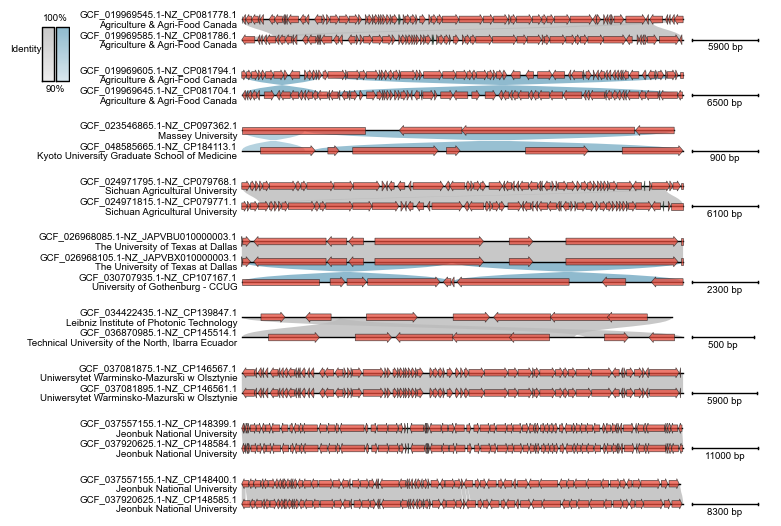

In [5]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

fig = plt.figure(figsize=(7.5, 7.5))
ax_y = 1
for idx, nodes in enumerate(networks, 1):
    acc_list, contig_dict = contig_alignment(sorted(nodes))
    ax_y = ax_y - len(nodes)*0.027
    ax_sequence_align = fig.add_axes([0.25,ax_y,1-0.235,len(nodes)*0.027])
    ax_y = ax_y - 0.02
    alignment_draw(ax_sequence_align, acc_list, contig_dict, align_result[idx])

ax_colorbar = fig.add_axes([0.04,0.9,0.04,0.08])
draw_colorbar_legend(ax_colorbar, rel_x=0.1, ID_MIN=90, width=0.08)
ax_colorbar.axis("off")

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_identical_trans_rep.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_identical_trans_rep.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()